In [13]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde

def plot_phase_space(x, y, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(6,5))
    
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=0.5)
    z = kde(xy)
    
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    
    sc = ax.scatter(x, y, c=z, s=5, cmap='viridis', alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    
    cbar = fig.colorbar(sc, ax=ax, orientation='vertical', label='Densidad de partículas')
    
    plt.tight_layout()
    plt.show()


def plot_phase_space_4panel(
    x, xp, y, yp,
    filename="phase_space_4panel",
    save=True,
    units_already_mm_mrad=True,
    bw_method=0.5,
    point_size=5,
    alpha=0.85,
    cmap="viridis",
    label_fontsize=16,
    tick_fontsize=13,
    cbar_fontsize=13,
    figsize=(13, 10)
):
    """
    Plotea en una figura 2x2:

        x  - x'
        y  - y'
        x  - y
        x' - y'

    Guarda el PDF en la carpeta actual.
    """

    x = np.asarray(x)
    xp = np.asarray(xp)
    y = np.asarray(y)
    yp = np.asarray(yp)

    if not units_already_mm_mrad:
        x = x * 1e3
        y = y * 1e3
        xp = xp * 1e3
        yp = yp * 1e3

    def density_scatter(ax, a, b, xlabel, ylabel):
        a = np.asarray(a)
        b = np.asarray(b)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        xy = np.vstack([a, b])

        try:
            kde = gaussian_kde(xy, bw_method=bw_method)
            z = kde(xy)

            idx = z.argsort()
            a = a[idx]
            b = b[idx]
            z = z[idx]

            sc = ax.scatter(
                a, b,
                c=z,
                s=point_size,
                cmap=cmap,
                alpha=alpha,
                edgecolors="none"
            )

            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label("Densidad de partículas", fontsize=cbar_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)

        except Exception:
            ax.scatter(
                a, b,
                s=point_size,
                alpha=alpha,
                edgecolors="none"
            )

        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.grid(True, alpha=0.3)

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    density_scatter(axs[0, 0], x, xp, r"$x$ [mm]", r"$x'$ [mrad]")
    density_scatter(axs[0, 1], y, yp, r"$y$ [mm]", r"$y'$ [mrad]")
    density_scatter(axs[1, 0], x, y, r"$x$ [mm]", r"$y$ [mm]")
    density_scatter(axs[1, 1], xp, yp, r"$x'$ [mrad]", r"$y'$ [mrad]")

    fig.tight_layout()

    if save:
        pdf_path = Path.cwd() / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Guardado en: {pdf_path}")

    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


TRAVEL final values
-------------------

X-X'
emit_x   = 0.218755 pi mm mrad
beta_x   = 0.010784 m/rad
alpha_x  = 0.035122
sigma_x  = 0.642373 mm
sigma_xp = 59.601535 mrad

Y-Y'
emit_y   = 0.070804 pi mm mrad
beta_y   = 0.011343 m/rad
alpha_y  = -1.080316
sigma_y  = 0.374804 mm
sigma_yp = 48.641566 mrad

Other
s        = 3.326500 m
sigma_p  = 1.074810e-03 MeV/c
sigma_E  = 6.144838e-06 MeV
Guardado en: /home/guest/tfm_pedro/Validation-of-linear-ion-accelerator/travel/phase_space_4panel.pdf


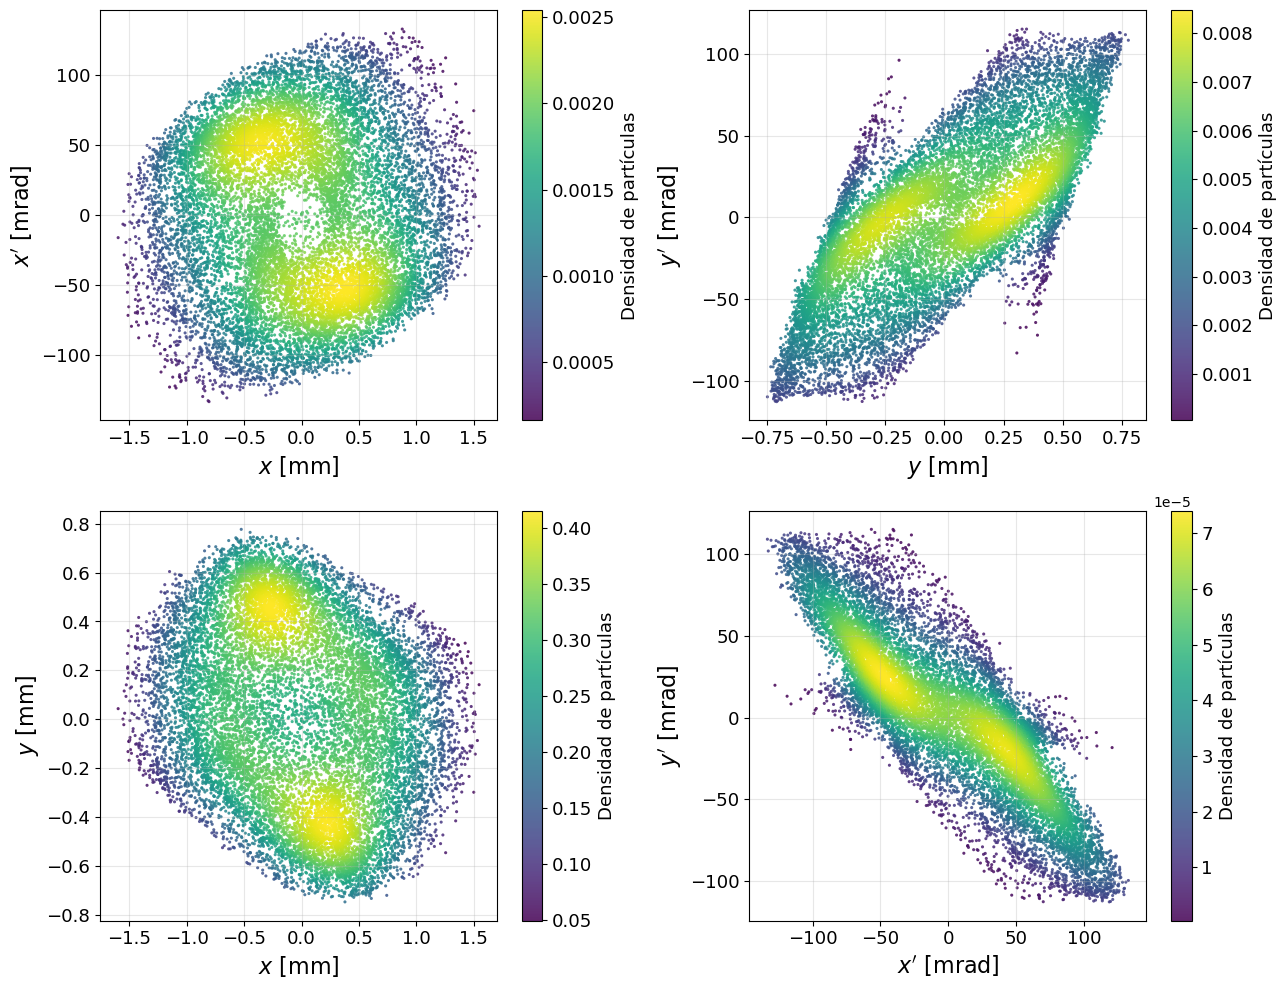

In [14]:
file = "lebt_travel_rms.txt"

data_rms = np.loadtxt(file, skiprows=1)
data_rms = np.atleast_2d(data_rms)

row = data_rms[-1]   # última fila / salida final

card = row[0]
card_type = row[1]
L = row[2]
s = L

sigma_x = row[5] * 1e3       # mm
sigma_xp = row[6] * 1e3      # mrad
sigma_y = row[7] * 1e3       # mm
sigma_yp = row[8] * 1e3      # mrad

sigma_p = row[13] * 1e3      # MeV/c
sigma_E = row[14] * 1e3      # MeV

emit_x = row[17] * 1e6       # pi mm mrad
emit_y = row[20] * 1e6       # pi mm mrad

alpha_x = row[27]
beta_x = row[28]
alpha_y = row[29]
beta_y = row[30]


data = np.loadtxt("lebt_travel.txt", skiprows=1)

x = data[:, 0] * 10    # cm -> mm
xp = data[:, 1] * 1e3  # rad -> mrad
y = data[:, 2] * 10    # cm -> mm
yp = data[:, 3] * 1e3  # rad -> mrad


print("TRAVEL final values")
print("-------------------")

print("\nX-X'")
print(f"emit_x   = {emit_x:.6f} pi mm mrad")
print(f"beta_x   = {beta_x:.6f} m/rad")
print(f"alpha_x  = {alpha_x:.6f}")
print(f"sigma_x  = {sigma_x:.6f} mm")
print(f"sigma_xp = {sigma_xp:.6f} mrad")

print("\nY-Y'")
print(f"emit_y   = {emit_y:.6f} pi mm mrad")
print(f"beta_y   = {beta_y:.6f} m/rad")
print(f"alpha_y  = {alpha_y:.6f}")
print(f"sigma_y  = {sigma_y:.6f} mm")
print(f"sigma_yp = {sigma_yp:.6f} mrad")

print("\nOther")
print(f"s        = {s:.6f} m")
print(f"sigma_p  = {sigma_p:.6e} MeV/c")
print(f"sigma_E  = {sigma_E:.6e} MeV")


plot_phase_space_4panel(
    x=x,
    xp=xp,
    y=y,
    yp=yp,
    filename="phase_space_4panel",
)